# Passos Mágicos — Modelo Preditivo de Risco de Defasagem

**Datathon PosTech | Associação Passos Mágicos**

Este notebook responde à **Pergunta 9** do desafio:

> *"Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho ou aumento da defasagem? Construa um modelo preditivo que mostre uma probabilidade do aluno ou aluna entrar em risco de defasagem."*

### Estratégia geral

A base `datathon.xlsx` traz **3 fotografias anuais** do PEDE (2022, 2023 e 2024), com um número
relevante de alunos em comum entre os anos. Em vez de tratar cada ano como uma amostra
independente (como no notebook exploratório inicial), vamos montar um **painel longitudinal por
aluno (RA)** e transformar o problema em uma pergunta genuinamente preditiva:

> Dados os indicadores do aluno **no ano corrente (t)**, qual a probabilidade de ele estar
> **defasado no ano seguinte (t+1)**?

Essa escolha evita **vazamento de dados (data leakage)** — o erro mais comum nesse tipo de
problema — porque o modelo nunca vê, para nenhum aluno, informação do próprio ano que está
tentando prever.

O notebook segue as etapas pedidas: **feature engineering → separação treino/teste → modelagem →
avaliação dos resultados**, e termina com uma aplicação prática: uma lista priorizada dos alunos
da coorte 2024 com maior probabilidade de risco no próximo ciclo.


In [1]:
import pandas as pd
import numpy as np
import re
import datetime
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              roc_curve, precision_recall_curve, average_precision_score)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

CAMINHO_BASE = "datathon.xlsx"  # ajuste o caminho se necessário


## 1. Carregamento e consolidação da base

O arquivo tem 3 abas (`PEDE2022`, `PEDE2023`, `PEDE2024`), uma por ano de pesquisa. Cada aba tem
**nomes de coluna diferentes** para os mesmos conceitos (ex.: `INDE 22` vs `INDE 2023` vs
`INDE 2024`; `Defas` vs `Defasagem`), então o primeiro passo é harmonizar tudo em um único
**painel (long format)**: uma linha por aluno × ano.


In [2]:
xls = pd.ExcelFile(CAMINHO_BASE)
d22 = pd.read_excel(xls, "PEDE2022")
d23 = pd.read_excel(xls, "PEDE2023")
d24 = pd.read_excel(xls, "PEDE2024")

for nome, d in [("PEDE2022", d22), ("PEDE2023", d23), ("PEDE2024", d24)]:
    print(f"{nome}: {d.shape[0]} alunos, {d.shape[1]} colunas")


PEDE2022: 860 alunos, 42 colunas
PEDE2023: 1014 alunos, 48 colunas
PEDE2024: 1156 alunos, 50 colunas


In [3]:
def harmonize(df, ano, inde_col, pedra_col, idade_col, nome_col, mat_col, por_col, ing_col,
              fase_ideal_col, defas_col):
    """Renomeia as colunas de uma aba anual para um esquema comum entre 2022/2023/2024."""
    out = pd.DataFrame()
    out["RA"] = df["RA"].astype(str)
    out["Ano"] = ano
    out["Fase_raw"] = df["Fase"].astype(str)
    out["Nome"] = df[nome_col]
    out["Idade"] = df[idade_col]
    out["Genero"] = df["Gênero"]
    out["Ano_ingresso"] = df["Ano ingresso"]
    out["Instituicao"] = df["Instituição de ensino"]
    out["Pedra"] = df[pedra_col]
    out["INDE"] = df[inde_col]
    out["IAA"] = df["IAA"]
    out["IEG"] = df["IEG"]
    out["IPS"] = df["IPS"]
    out["IPP"] = df["IPP"] if "IPP" in df.columns else np.nan
    out["IDA"] = df["IDA"]
    out["Nota_Mat"] = df[mat_col]
    out["Nota_Por"] = df[por_col]
    out["IPV"] = df["IPV"]
    out["IAN"] = df["IAN"]
    out["Defasagem"] = df[defas_col]
    return out

p22 = harmonize(d22, 2022, "INDE 22", "Pedra 22", "Idade 22", "Nome", "Matem", "Portug", "Inglês",
                 "Fase ideal", "Defas")
p23 = harmonize(d23, 2023, "INDE 2023", "Pedra 2023", "Idade", "Nome Anonimizado", "Mat", "Por", "Ing",
                 "Fase Ideal", "Defasagem")
p24 = harmonize(d24, 2024, "INDE 2024", "Pedra 2024", "Idade", "Nome Anonimizado", "Mat", "Por", "Ing",
                 "Fase Ideal", "Defasagem")

panel = pd.concat([p22, p23, p24], ignore_index=True)
print("Painel consolidado:", panel.shape)


Painel consolidado: (3030, 20)


### 1.1 Qualidade dos dados

Antes de qualquer modelagem, vale a pena checar a qualidade dos dados brutos — e a base tem
algumas pegadinhas reais que passariam despercebidas em uma análise superficial:

1. **`Idade` (aba 2023): bug clássico do Excel.** 399 registros trazem a idade como uma *data*
   do tipo `1900-01-08` em vez de um número. Isso acontece quando uma célula numérica pequena
   (ex.: `8`) é formatada como data — o Excel conta os dias a partir de 1900-01-01, então o
   número `8` vira "08/01/1900". Cruzando com a `Data de Nasc.` da mesma aba, confirma-se que o
   **dia do mês da pseudo-data é a idade real**.
2. **`INDE` (aba 2024): 38 alunos novos com o texto `"INCLUIR"`** no lugar da nota — são alunos
   recém-ingressos que ainda não tinham INDE consolidado no fechamento da pesquisa. Precisam virar
   `NaN`, não zero.
3. **`Gênero`: rótulos diferentes por ano** (`Menina`/`Menino` em 2022 vs `Feminino`/`Masculino`
   em 2023/2024) — sem padronizar, o modelo trataria como 4 categorias em vez de 2.


In [4]:
# 1) Corrigir bug de datas do Excel na coluna Idade
def fix_idade(v):
    if isinstance(v, (pd.Timestamp, datetime.datetime)):
        return v.day
    return v

antes = panel["Idade"].apply(lambda x: isinstance(x, (pd.Timestamp, datetime.datetime))).sum()
panel["Idade"] = panel["Idade"].apply(fix_idade)
panel["Idade"] = pd.to_numeric(panel["Idade"], errors="coerce")
print(f"Registros de Idade corrigidos (bug de data do Excel): {antes}")

# 2) INDE com placeholder textual "INCLUIR" -> NaN
qtd_incluir = (panel["INDE"] == "INCLUIR").sum()
panel["INDE"] = pd.to_numeric(panel["INDE"], errors="coerce")
print(f"Registros de INDE com placeholder 'INCLUIR' convertidos para NaN: {qtd_incluir}")

# 3) Harmonizar rótulos de gênero
panel["Genero"] = panel["Genero"].replace({"Menina": "Feminino", "Menino": "Masculino"})
print("Categorias de Gênero após harmonização:", sorted(panel["Genero"].dropna().unique()))


Registros de Idade corrigidos (bug de data do Excel): 399
Registros de INDE com placeholder 'INCLUIR' convertidos para NaN: 38
Categorias de Gênero após harmonização: ['Feminino', 'Masculino']


### 1.2 Harmonizando a `Fase`

A codificação de fase também muda de formato a cada ano: `2022` usa números puros (`0`–`7`),
`2023` usa texto (`"FASE 3"`, `"ALFA"`), e `2024` mistura fase + turma (`"3P"`, `"ALFA"`).
Extraímos um valor numérico comparável entre os três anos (`ALFA` = fase pré-inicial = `0`).


In [5]:
def extract_fase_num(s):
    s = str(s).upper().strip()
    if s.startswith("ALFA"):
        return 0
    m = re.search(r"\d+", s)
    return int(m.group()) if m else np.nan

panel["Fase_num"] = panel["Fase_raw"].apply(extract_fase_num)
print(panel[["Ano", "Fase_raw", "Fase_num"]].drop_duplicates().sort_values(["Ano", "Fase_num"]).head(12).to_string(index=False))


 Ano Fase_raw  Fase_num
2022        0         0
2022        1         1
2022        2         2
2022        3         3
2022        4         4
2022        5         5
2022        6         6
2022        7         7
2023     ALFA         0
2023   FASE 1         1
2023   FASE 2         2
2023   FASE 3         3


## 2. O painel é longitudinal: quantos alunos se repetem entre os anos?

Esse é o ponto-chave que viabiliza um modelo preditivo de verdade (e não apenas uma regressão
contemporânea): boa parte dos alunos aparece em mais de um ano da pesquisa.


In [6]:
ra_por_ano = {ano: set(panel.loc[panel["Ano"] == ano, "RA"]) for ano in [2022, 2023, 2024]}
print("Alunos em 2022:", len(ra_por_ano[2022]))
print("Alunos em 2023:", len(ra_por_ano[2023]))
print("Alunos em 2024:", len(ra_por_ano[2024]))
print("Presentes em 2022 E 2023:", len(ra_por_ano[2022] & ra_por_ano[2023]))
print("Presentes em 2023 E 2024:", len(ra_por_ano[2023] & ra_por_ano[2024]))
print("Presentes nos 3 anos:      ", len(ra_por_ano[2022] & ra_por_ano[2023] & ra_por_ano[2024]))


Alunos em 2022: 860
Alunos em 2023: 1014
Alunos em 2024: 1156
Presentes em 2022 E 2023: 600
Presentes em 2023 E 2024: 765
Presentes nos 3 anos:       468


## 3. Por que não podemos simplesmente usar IDA/IEG/IPS do mesmo ano

Uma armadilha comum (presente na primeira versão do notebook exploratório) é treinar um modelo
para prever `RiscoDefasagem` usando indicadores **do mesmo ano**. Isso não é tecnicamente
"vazamento" no sentido estrito, mas é uma **pergunta de negócio diferente e menos útil**: descreve
a situação atual do aluno, e não antecipa o futuro.

Além disso, vale registrar um achado da exploração dos dados que evita redundância no modelo: o
indicador **IAN** é, na prática, uma **função em degraus da própria `Defasagem`** do mesmo ano
(cada faixa de defasagem mapeia para um valor fixo de IAN). Ou seja, IAN e Defasagem carregam
quase a mesma informação — não faz sentido usar os dois como *preditores redundantes* do mesmo
ano no modelo.


In [7]:
tabela_ian_defas = panel.groupby("Defasagem")["IAN"].agg(["mean", "min", "max", "count"])
print("IAN por faixa de Defasagem (mesmo ano) — quase uma função determinística:")
print(tabela_ian_defas)
print()
print("Correlação IAN x Defasagem (mesmo ano):", panel[["IAN", "Defasagem"]].corr().iloc[0, 1].round(3))


IAN por faixa de Defasagem (mesmo ano) — quase uma função determinística:
           mean   min   max  count
Defasagem                         
-5          2.5   2.5   2.5      1
-4          2.5   2.5   2.5      5
-3          2.5   2.5   2.5     39
-2          5.0   5.0   5.0    383
-1          5.0   5.0   5.0   1259
 0         10.0  10.0  10.0   1152
 1         10.0  10.0  10.0    165
 2         10.0  10.0  10.0     24
 3         10.0  10.0  10.0      2

Correlação IAN x Defasagem (mesmo ano): 0.856


## 4. Feature engineering

Com o painel limpo, criamos os atributos que alimentarão o modelo — todos calculados **a partir
do ano corrente (t)**, nunca do ano-alvo:

- **`Anos_na_PM`** = tempo de programa (`Ano` − `Ano_ingresso`), um proxy de "dose" de
  intervenção recebida.
- **`Pedra_ordinal`** = codificação ordinal de `Pedra` (Quartzo < Ágata < Ametista < Topázio),
  em vez de one-hot, já que existe uma ordem natural entre as pedras.
- **`Instituicao_grp`** = agrupamento de `Instituição de ensino` em `Pública` / `Privada` /
  `Concluiu/Universitário` / `Outra`, já que o texto bruto varia entre anos (ex.: `"Escola
  Pública"` vs `"Pública"`).

Também decidimos, conscientemente, **não usar** algumas colunas no modelo:

- `Nota_Ing` (inglês): só ~35% preenchida em todos os anos — ruído demais.
- `Cg`/`Cf`/`Ct` (rankings), `Indicado` (indicação de bolsa), `Atingiu PV` e as colunas `Rec Av1-4`:
  existem **preenchidas apenas na aba de 2022** — nas abas de 2023 e 2024 essas colunas existem no
  cabeçalho, mas vêm **100% vazias**. Usá-las geraria um atributo que na prática só teria sinal
  para uma das duas coortes de transição.


In [8]:
panel["Anos_na_PM"] = panel["Ano"] - panel["Ano_ingresso"]

pedra_map = {"Quartzo": 1, "Ágata": 2, "Ametista": 3, "Topázio": 4}
panel["Pedra_ordinal"] = panel["Pedra"].map(pedra_map)

def group_instituicao(s):
    if pd.isna(s):
        return "Outra/NI"
    s_low = str(s).lower()
    if "públic" in s_low or "publica" in s_low:
        return "Pública"
    if "privada" in s_low:
        return "Privada"
    if "concluiu" in s_low or "universit" in s_low:
        return "Concluiu/Universitário"
    return "Outra/NI"

panel["Instituicao_grp"] = panel["Instituicao"].apply(group_instituicao)

feature_cols = ["Fase_num", "Idade", "Anos_na_PM", "Genero", "Instituicao_grp", "Pedra_ordinal",
                "INDE", "IAA", "IEG", "IPS", "IPP", "IDA", "Nota_Mat", "Nota_Por", "IPV", "Defasagem"]

print("% de preenchimento de cada atributo candidato, por ano:")
print((panel.groupby("Ano")[feature_cols].apply(lambda g: g.notnull().mean()) * 100).round(1))


% de preenchimento de cada atributo candidato, por ano:
      Fase_num  Idade  Anos_na_PM  Genero  Instituicao_grp  Pedra_ordinal  \
Ano                                                                         
2022     100.0  100.0       100.0   100.0            100.0          100.0   
2023     100.0  100.0       100.0   100.0            100.0           67.6   
2024     100.0  100.0       100.0   100.0            100.0           71.7   

       INDE    IAA    IEG    IPS   IPP    IDA  Nota_Mat  Nota_Por    IPV  \
Ano                                                                        
2022  100.0  100.0  100.0  100.0   0.0  100.0      99.8      99.8  100.0   
2023   91.8   93.8   92.5   93.2  92.5   92.4      92.4      92.4   92.5   
2024   91.2   91.2  100.0   91.2  91.2   91.3      90.9      90.8   91.2   

      Defasagem  
Ano              
2022      100.0  
2023      100.0  
2024      100.0  


## 5. Construindo o dataset de transições (t → t+1) e o alvo

Para cada par de anos consecutivos com alunos em comum (**2022→2023** e **2023→2024**),
cruzamos os atributos do ano `t` com a `Defasagem` observada no ano `t+1`. O alvo binário é:

$$\text{Em\_Risco\_Defasagem\_t1} = 1 \iff \text{Defasagem}_{t+1} < 0$$

(ou seja, o aluno está **abaixo do nível ideal** no ano seguinte). Empilhamos as duas transições
em um único dataset de modelagem — isso também aumenta o volume de dados de treino.


In [9]:
base = panel[["RA", "Ano"] + feature_cols].copy()

def build_transitions(base, t):
    t1 = t + 1
    df_t = base[base["Ano"] == t].drop(columns=["Ano"]).add_suffix("_t").rename(columns={"RA_t": "RA"})
    df_t1 = base[base["Ano"] == t1][["RA", "Defasagem"]].rename(columns={"Defasagem": "Defasagem_t1"})
    merged = df_t.merge(df_t1, on="RA", how="inner")
    merged["Ano_t"] = t
    return merged

trans_22_23 = build_transitions(base, 2022)
trans_23_24 = build_transitions(base, 2023)

modelo_df = pd.concat([trans_22_23, trans_23_24], ignore_index=True)
modelo_df["Em_Risco_Defasagem_t1"] = (modelo_df["Defasagem_t1"] < 0).astype(int)
modelo_df["IPP_disponivel_t"] = modelo_df["IPP_t"].notnull().astype(int)

print("Transições 2022→2023:", trans_22_23.shape[0], "alunos")
print("Transições 2023→2024:", trans_23_24.shape[0], "alunos")
print("Dataset de modelagem final:", modelo_df.shape)
print("Alunos únicos (algumas linhas repetem RA, uma por transição):", modelo_df['RA'].nunique())
print()
print("Prevalência do alvo por coorte de transição:")
print(modelo_df.groupby("Ano_t")["Em_Risco_Defasagem_t1"].mean().rename("proporção em risco no ano seguinte"))


Transições 2022→2023: 600 alunos
Transições 2023→2024: 765 alunos
Dataset de modelagem final: (1365, 21)
Alunos únicos (algumas linhas repetem RA, uma por transição): 897

Prevalência do alvo por coorte de transição:
Ano_t
2022    0.610000
2023    0.402614
Name: proporção em risco no ano seguinte, dtype: float64


> **Achado interessante (conecta com a Pergunta 10 — efetividade do programa):** a proporção
> de alunos que acabam defasados no ano seguinte **cai de ~61% (coorte 2022→2023) para ~40%
> (coorte 2023→2024)**. Isso é evidência adicional, independente da análise por fase/pedra, de que
> a taxa de risco de defasagem vem diminuindo ao longo dos ciclos do programa.


## 6. Separação treino/teste — cuidado com vazamento de aluno

Como o mesmo aluno pode contribuir com **duas linhas** (uma por transição, se ele aparece nos 3
anos), um `train_test_split` comum poderia colocar a transição 2022→2023 de um aluno no treino e a
2023→2024 do **mesmo aluno** no teste — vazando informação sobre ele entre os conjuntos. Usamos
`GroupShuffleSplit` agrupando por `RA`, garantindo que cada aluno fique **inteiramente** em treino
ou em teste.


In [10]:
numeric_features = ["Fase_num_t", "Idade_t", "Anos_na_PM_t", "Pedra_ordinal_t", "INDE_t", "IAA_t",
                     "IEG_t", "IPS_t", "IPP_t", "IDA_t", "Nota_Mat_t", "Nota_Por_t", "IPV_t",
                     "Defasagem_t", "IPP_disponivel_t"]
categorical_features = ["Genero_t", "Instituicao_grp_t", "Ano_t"]

X = modelo_df[numeric_features + categorical_features].copy()
X["Ano_t"] = X["Ano_t"].astype(str)
y = modelo_df["Em_Risco_Defasagem_t1"]
groups = modelo_df["RA"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

overlap = set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])
print(f"Treino: {X_train.shape[0]} linhas | Teste: {X_test.shape[0]} linhas")
print(f"Alunos (RA) presentes em treino E teste ao mesmo tempo: {len(overlap)}  (precisa ser 0)")
print(f"Prevalência do alvo — treino: {y_train.mean():.1%} | teste: {y_test.mean():.1%}")


Treino: 1012 linhas | Teste: 353 linhas
Alunos (RA) presentes em treino E teste ao mesmo tempo: 0  (precisa ser 0)
Prevalência do alvo — treino: 49.9% | teste: 47.9%


## 7. Pré-processamento e modelagem

Pipeline de pré-processamento:
- **Numéricas:** imputação pela mediana + padronização (`StandardScaler`).
- **Categóricas:** imputação pela moda + `OneHotEncoder`.

Testamos dois modelos:
- **Regressão Logística** (`class_weight="balanced"`) — baseline simples e interpretável.
- **Random Forest** — captura não linearidades e interações entre indicadores.


In [11]:
preprocess = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                       ("scaler", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                       ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features)
])

modelos = {
    "Regressão Logística": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=400, max_depth=8, min_samples_leaf=5,
                                             class_weight="balanced", random_state=42)
}

pipelines = {}
resultados = {}

for nome, clf in modelos.items():
    pipe = Pipeline([("prep", preprocess), ("clf", clf)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    pipelines[nome] = pipe
    resultados[nome] = {"y_pred": y_pred, "y_proba": y_proba}

    print("=" * 72)
    print(nome)
    print(classification_report(y_test, y_pred, target_names=["Sem risco", "Em risco"]))
    print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3),
          "| PR-AUC:", round(average_precision_score(y_test, y_proba), 3))


Regressão Logística
              precision    recall  f1-score   support

   Sem risco       0.77      0.80      0.79       184
    Em risco       0.77      0.75      0.76       169

    accuracy                           0.77       353
   macro avg       0.77      0.77      0.77       353
weighted avg       0.77      0.77      0.77       353

ROC-AUC: 0.872 | PR-AUC: 0.873
Random Forest
              precision    recall  f1-score   support

   Sem risco       0.81      0.81      0.81       184
    Em risco       0.79      0.80      0.80       169

    accuracy                           0.80       353
   macro avg       0.80      0.80      0.80       353
weighted avg       0.80      0.80      0.80       353

ROC-AUC: 0.9 | PR-AUC: 0.892


## 8. Avaliação visual: matrizes de confusão e curva ROC


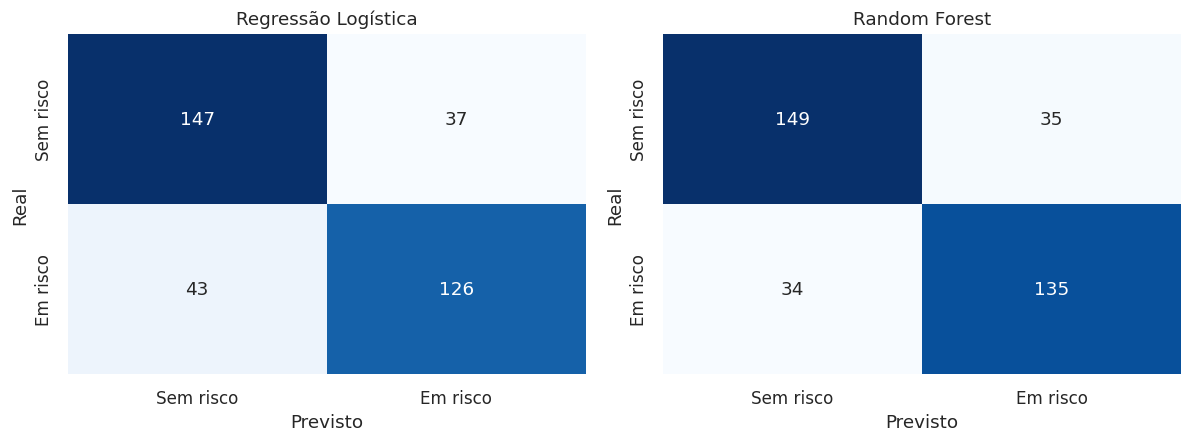

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, (nome, res) in zip(axes, resultados.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Sem risco", "Em risco"], yticklabels=["Sem risco", "Em risco"])
    ax.set_title(nome)
    ax.set_xlabel("Previsto")
    ax.set_ylabel("Real")
plt.tight_layout()
plt.show()


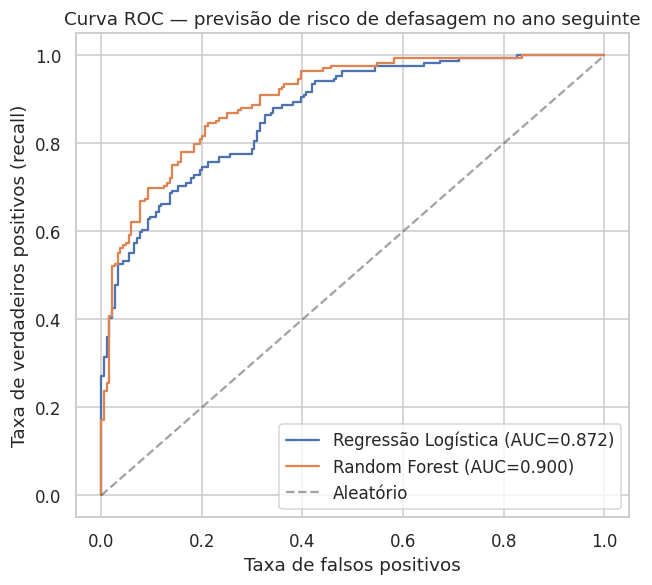

In [13]:
plt.figure(figsize=(6, 5.5))
for nome, res in resultados.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    auc = roc_auc_score(y_test, res["y_proba"])
    plt.plot(fpr, tpr, label=f"{nome} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Aleatório")
plt.xlabel("Taxa de falsos positivos")
plt.ylabel("Taxa de verdadeiros positivos (recall)")
plt.title("Curva ROC — previsão de risco de defasagem no ano seguinte")
plt.legend()
plt.tight_layout()
plt.show()


**Leitura dos resultados:** os dois modelos têm desempenho bom para um problema social real
(ROC-AUC ~0,87–0,90), com precisão e recall próximos de 0,80 para a classe "em risco" — ou seja, o
modelo erra pouco tanto ao apontar falsos alarmes quanto ao deixar passar alunos que de fato
entrarão em defasagem. O **Random Forest** tem uma pequena vantagem em todas as métricas e será o
modelo escolhido para as próximas seções.


## 9. O que mais pesa na previsão? (importância dos atributos)


num__Defasagem_t                  0.161799
num__IPV_t                        0.125081
num__Fase_num_t                   0.116649
num__INDE_t                       0.102019
num__Idade_t                      0.082493
num__IPP_t                        0.061825
num__IDA_t                        0.046869
num__Nota_Por_t                   0.043494
cat__Instituicao_grp_t_Pública    0.040939
num__IEG_t                        0.036147
num__Nota_Mat_t                   0.034175
num__IPS_t                        0.030028
dtype: float64


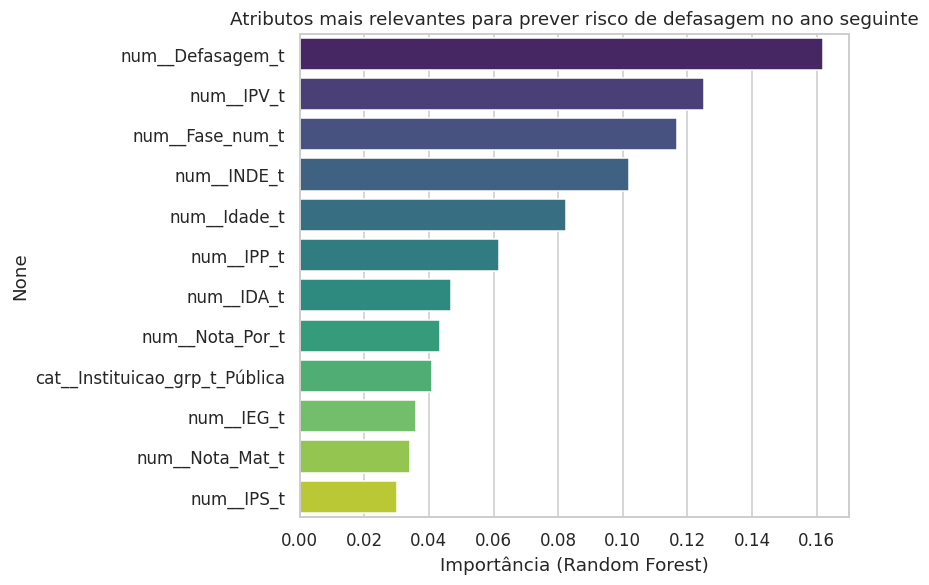

In [14]:
modelo_final_nome = "Random Forest"
pipe_final = pipelines[modelo_final_nome]

feat_names = pipe_final.named_steps["prep"].get_feature_names_out()
importancias = pd.Series(pipe_final.named_steps["clf"].feature_importances_, index=feat_names)
importancias = importancias.sort_values(ascending=False).head(12)

plt.figure(figsize=(8, 5.5))
sns.barplot(x=importancias.values, y=importancias.index, palette="viridis")
plt.xlabel("Importância (Random Forest)")
plt.title("Atributos mais relevantes para prever risco de defasagem no ano seguinte")
plt.tight_layout()
plt.show()

print(importancias)


**Leitura:** a defasagem **atual** (`Defasagem_t`) e o ponto de virada (`IPV_t`) são os
sinais mais fortes — ou seja, defasagem tende a **persistir** se nada muda, e o quanto o aluno já
está perto do seu "ponto de virada" ajuda a prever o próximo ano. `Fase_num_t` e `INDE_t` também
pesam bastante: alunos em fases mais avançadas e com nota global mais alta têm menor risco. Os
indicadores de engajamento (`IEG`) e psicossocial (`IPS`) aparecem com peso menor, mas ainda
presentes — reforçando que, isoladamente, eles são preditores mais fracos do que o desempenho
acadêmico e a trajetória de defasagem em si (mesmo achado da análise exploratória de correlações).


## 10. Ajustando o limiar de decisão para o uso real

Por padrão, um classificador usa 0,5 como limiar de corte. Mas, em um programa social, o custo de
**não identificar** um aluno em risco (falso negativo) é maior do que o custo de **checar
manualmente** um aluno que no fim não estava em risco (falso positivo). Por isso vale olhar a
curva precisão-recall e escolher um limiar mais sensível à classe "em risco".


Limiar que maximiza F1: 0.470  ->  precisão=0.79, recall=0.85
Limiar para recall~85%:     0.446  ->  precisão=0.77, recall=0.85


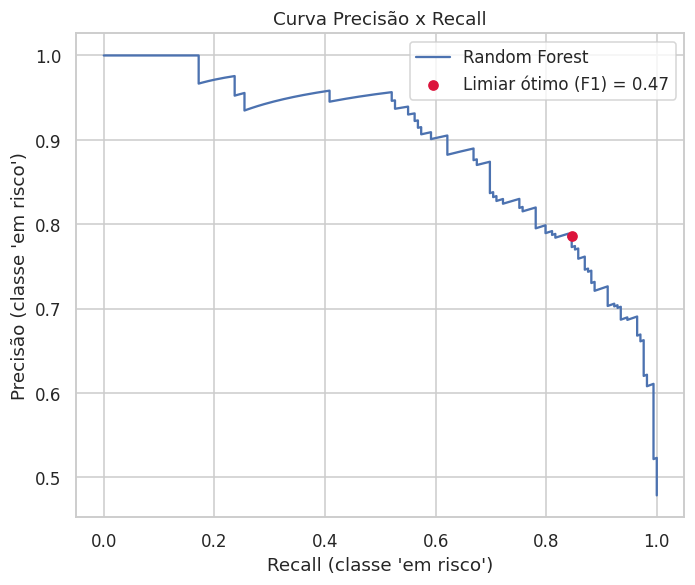

In [15]:
prec, rec, thr = precision_recall_curve(y_test, resultados[modelo_final_nome]["y_proba"])
f1 = 2 * prec * rec / (prec + rec + 1e-9)
idx_f1 = np.argmax(f1)

plt.figure(figsize=(6.5, 5.5))
plt.plot(rec, prec, label="Random Forest")
plt.scatter(rec[idx_f1], prec[idx_f1], color="crimson", zorder=5,
            label=f"Limiar ótimo (F1) = {thr[idx_f1]:.2f}")
plt.xlabel("Recall (classe 'em risco')")
plt.ylabel("Precisão (classe 'em risco')")
plt.title("Curva Precisão x Recall")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Limiar que maximiza F1: {thr[idx_f1]:.3f}  ->  precisão={prec[idx_f1]:.2f}, recall={rec[idx_f1]:.2f}")

alvo_recall = 0.85
idx_r = np.argmin(np.abs(rec[:-1] - alvo_recall))
print(f"Limiar para recall~{alvo_recall:.0%}:     {thr[idx_r]:.3f}  ->  precisão={prec[idx_r]:.2f}, recall={rec[idx_r]:.2f}")


## 11. Aplicação prática: priorizando a coorte 2024 para o próximo ciclo

Com o modelo treinado (usando as transições 2022→2023 e 2023→2024), podemos pontuar os alunos
**atualmente ativos em 2024** para estimar a probabilidade de cada um estar defasado no próximo
ciclo (2025) — ainda sem essa informação real disponível. É exatamente o uso pretendido pela
Pergunta 9: uma lista priorizada para a equipe pedagógica agir **antes** de a defasagem acontecer.


In [16]:
cohort_2024 = panel[panel["Ano"] == 2024].copy()
rename_map = {
    "Fase_num": "Fase_num_t", "Idade": "Idade_t", "Anos_na_PM": "Anos_na_PM_t", "Genero": "Genero_t",
    "Instituicao_grp": "Instituicao_grp_t", "Pedra_ordinal": "Pedra_ordinal_t", "INDE": "INDE_t",
    "IAA": "IAA_t", "IEG": "IEG_t", "IPS": "IPS_t", "IPP": "IPP_t", "IDA": "IDA_t",
    "Nota_Mat": "Nota_Mat_t", "Nota_Por": "Nota_Por_t", "IPV": "IPV_t", "Defasagem": "Defasagem_t"
}
cohort_X = cohort_2024.rename(columns=rename_map).copy()
cohort_X["IPP_disponivel_t"] = cohort_X["IPP_t"].notnull().astype(int)
cohort_X["Ano_t"] = "2024"

proba_2024 = pipe_final.predict_proba(cohort_X[numeric_features + categorical_features])[:, 1]

ranking = cohort_2024[["RA", "Nome", "Fase_raw", "Pedra", "INDE", "Defasagem"]].copy()
ranking["Probabilidade_Risco_2025"] = proba_2024
ranking = ranking.sort_values("Probabilidade_Risco_2025", ascending=False).reset_index(drop=True)

LIMIAR_PRIORIDADE = thr[idx_r]  # limiar orientado a recall alto, definido na seção 10
n_prioridade = (ranking["Probabilidade_Risco_2025"] >= LIMIAR_PRIORIDADE).sum()
print(f"Alunos da coorte 2024 sinalizados para atenção prioritária (prob. >= {LIMIAR_PRIORIDADE:.2f}): "
      f"{n_prioridade} de {len(ranking)} ({n_prioridade/len(ranking):.1%})")
print()
print("Top 15 alunos com maior probabilidade de risco de defasagem no próximo ciclo:")
print(ranking.head(15).to_string(index=False))


Alunos da coorte 2024 sinalizados para atenção prioritária (prob. >= 0.45): 626 de 1156 (54.2%)

Top 15 alunos com maior probabilidade de risco de defasagem no próximo ciclo:
     RA       Nome Fase_raw    Pedra     INDE  Defasagem  Probabilidade_Risco_2025
RA-1551 Aluno-1551       3P  Quartzo 5.971709         -2                  0.939590
 RA-381  Aluno-381       3G  Quartzo 5.940775         -2                  0.937840
RA-1299 Aluno-1299     ALFA Ametista 7.069728         -2                  0.937675
 RA-754  Aluno-754     ALFA  Quartzo 5.612700         -2                  0.936259
RA-1337 Aluno-1337     ALFA    Agata 6.015144         -2                  0.935332
 RA-568  Aluno-568       3F  Quartzo 5.545864         -2                  0.930974
RA-1055 Aluno-1055       1J    Agata 6.403041         -2                  0.929438
 RA-762  Aluno-762       2K  Quartzo 5.967733         -2                  0.928336
 RA-558  Aluno-558       3F  Quartzo 5.048055         -2                  0.92

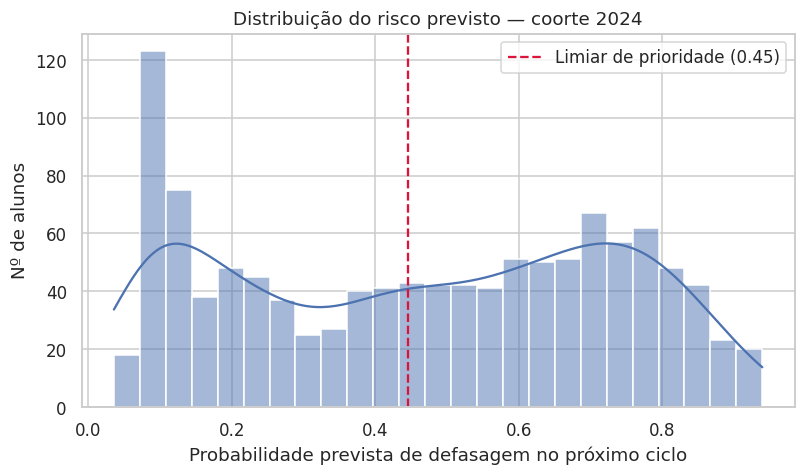

In [17]:
plt.figure(figsize=(7.5, 4.5))
sns.histplot(ranking["Probabilidade_Risco_2025"], bins=25, kde=True, color="#4C72B0")
plt.axvline(LIMIAR_PRIORIDADE, color="crimson", linestyle="--",
            label=f"Limiar de prioridade ({LIMIAR_PRIORIDADE:.2f})")
plt.xlabel("Probabilidade prevista de defasagem no próximo ciclo")
plt.ylabel("Nº de alunos")
plt.title("Distribuição do risco previsto — coorte 2024")
plt.legend()
plt.tight_layout()
plt.show()


## 12. Conclusões, limitações e próximos passos

**Principais achados do modelo:**
- É possível prever, com boa performance (ROC-AUC ≈ 0,90), se um aluno estará defasado no ano
  seguinte usando apenas indicadores do ano corrente — sem precisar esperar o resultado acontecer.
- A **defasagem atual e o ponto de virada (IPV)** são os sinais mais fortes de risco futuro: sem
  intervenção, defasagem tende a se perpetuar. `Fase` e `INDE` também têm peso relevante.
- A proporção de alunos que entram em risco no ano seguinte **caiu de ~61% para ~40%** entre as
  coortes 2022→2023 e 2023→2024, um indício adicional (via a ótica preditiva) de efetividade
  crescente do programa.

**Limitações a declarar de forma transparente:**
- Apenas 3 fotografias anuais (2022–2024) → só 2 transições possíveis; o modelo deve ser
  re-treinado a cada novo ciclo do PEDE para ganhar robustez.
- `IPP` só existe a partir de 2023 e `Cg`/`Cf`/`Ct`/`Indicado`/`Atingiu PV`/`Rec Av1-4` só existem
  preenchidos em 2022 — atributos com essa limitação estrutural foram tratados com cautela ou
  descartados do modelo.
- Alunos muito novos no programa (aparecem com `INDE = "INCLUIR"`) ainda não têm avaliação
  consolidada; eles devem ser repontuados assim que a primeira avaliação estiver disponível.
- O modelo é uma ferramenta de **priorização de apoio pedagógico e psicossocial**, não deve ser
  usado para decisões de exclusão, e seu desempenho por gênero e tipo de instituição deve ser
  monitorado ao longo do tempo para garantir equidade.

**Próximos passos sugeridos:**
1. Repontuar a coorte 2024 a cada novo ciclo e comparar a lista prevista com os casos reais de
   defasagem, recalibrando o limiar de decisão.
2. Incorporar o PEDE 2025 assim que disponível para uma terceira transição (2023→2024 e
   2024→2025), ampliando a base de treino.
3. Investigar, com a equipe pedagógica, os casos de maior probabilidade prevista para desenhar
   um plano de apoio individualizado antes que a defasagem se concretize.
